In [154]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

using mathemetical model to better understand the data we are looking at.

# Categories of Machine Learning

supervised learning
- models measured features against labels, either continous our discrete.
  - classification uses discrete labels, while regression uses continous labels.
unsupervised learning
- modeling without labels
  - clustering
  - dimensionality reduction
    - reduces the number of features in a dataset, while preserving as much information as possible.
semi-supervised learning

# Qualitative Examples of Machine Learning Applications

## Classification: Predicting discrete labels

picking a label based on measured features.
features: data that is measured
class labels: the label that is predicted based on the features
model: represenation of the relationship
model parameters: paramters tweaking the model to better fit the data
learning teaches the best model parameters to fit the data

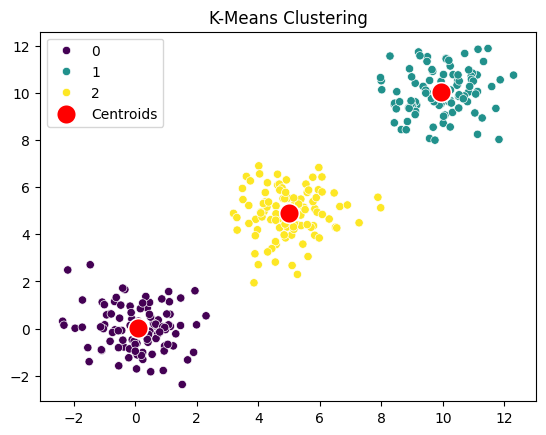

In [155]:
cluster1 = np.random.normal(loc=0, size=(100, 2))
cluster2 = np.random.normal(loc=5, size=(100, 2))
cluster3 = np.random.normal(loc=10, size=(100, 2))
data = np.vstack((cluster1, cluster2, cluster3))

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(data)

centroids = kmeans.cluster_centers_

x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=labels, palette='viridis', legend='full')
sns.scatterplot(x=centroids[:, 0], y=centroids[:, 1], c='red', s=200, label='Centroids')
plt.title('K-Means Clustering')
plt.legend()
plt.show()

## regression: predicting continous labels

<Axes: >

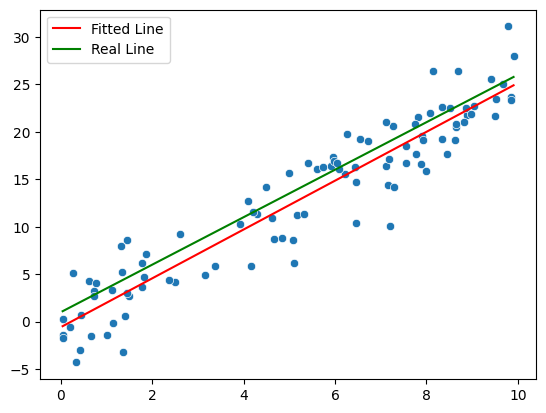

In [156]:
from scipy import stats

real_slope = 2.5
real_intercept = 1.0

x = np.random.rand(100) * 10
y = real_slope * x + real_intercept * np.random.randn(100) * 3

guess_slope, guess_intercept, _, _, _ = stats.linregress(x, y)

sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=guess_slope * x + guess_intercept, color='red', label='Fitted Line')
sns.lineplot(x=x, y=real_slope * x + real_intercept, color='green', label='Real Line')

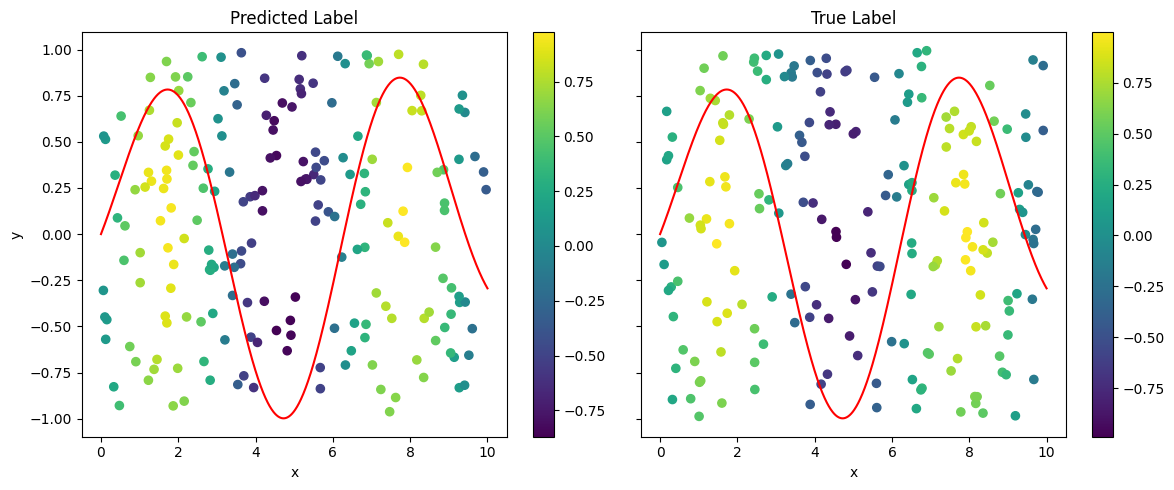

In [157]:
from sklearn.ensemble import RandomForestRegressor

size = 200

x = np.random.uniform(0, 10, size=size)
y = np.random.uniform(-1, 1, size=size)

true_label = np.sin(x) * np.cos(y)

X = np.column_stack((x, y))

model = RandomForestRegressor()

model.fit(X, true_label)

x_to_guess = np.random.uniform(0, 10, size=size)
y_to_guess = np.random.uniform(-1, 1, size=size)
predicted_label = model.predict(np.column_stack((x_to_guess, y_to_guess)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)


x_true_line = np.linspace(0, 10, 1000)
y_true_line = np.linspace(-1, 1, 1000)
true_y = np.sin(x_true_line) * np.cos(y_true_line)

p1 = axes[0].scatter(x_to_guess, y_to_guess, c=predicted_label, cmap="viridis", s=35)
axes[0].set_title("Predicted Label")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].plot(x_true_line, true_y, color='red', label='True Function')
fig.colorbar(p1, ax=axes[0])

p2 = axes[1].scatter(x, y, c=true_label, cmap="viridis", s=35)
axes[1].set_title("True Label")
axes[1].set_xlabel("x")
axes[1].plot(x_true_line, true_y, color='red', label='True Function')
fig.colorbar(p2, ax=axes[1])

plt.tight_layout()
plt.show()

# clutering: infering labels on unlabeled data

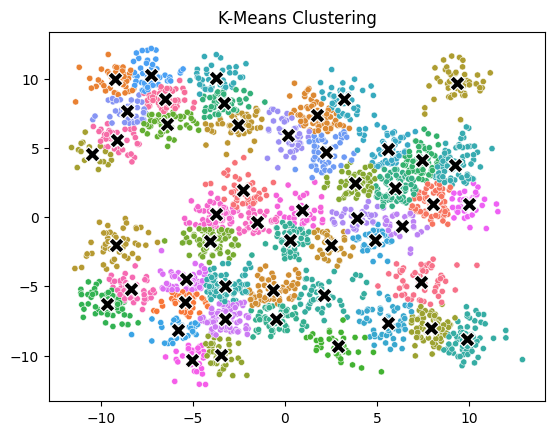

In [158]:
clusters = []
n_clusters = 50
for i in range(n_clusters):
    center = np.random.uniform(-10, 10, size=2)
    cluster = np.random.normal(loc=center, size=(50, 2))
    clusters.append(cluster)
data = np.vstack(clusters)

kmeans = KMeans(n_clusters=n_clusters)
labels = kmeans.fit_predict(data)

centroids = kmeans.cluster_centers_

palette = sns.color_palette("husl", n_clusters)

sns.scatterplot(
    x=data[:, 0],
    y=data[:, 1],
    hue=labels,
    palette=palette,
    legend=False,   # remove legend
    s=20
)
sns.scatterplot(
    x=centroids[:, 0],
    y=centroids[:, 1],
    color='black',
    s=120,
    marker='X',
    legend=False
)

plt.title('K-Means Clustering')
plt.show()

## dimensionality reduction: inferring structure of unlabeled data

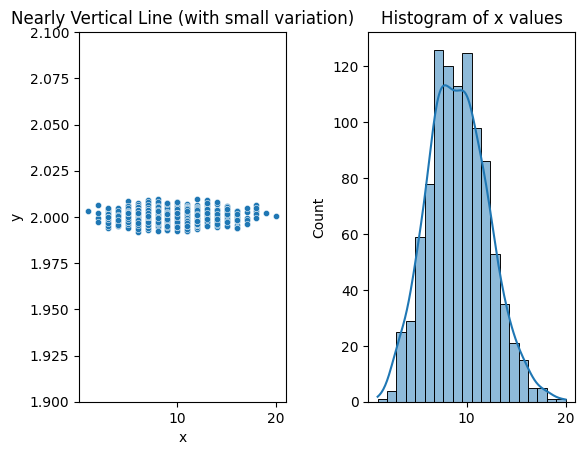

<Figure size 640x480 with 0 Axes>

In [176]:
size = 1000
y = np.repeat(2.0, size) + np.random.normal(0, 0.003, size=size)
x = np.random.poisson(lam=9, size=size)

fig, ax = plt.subplots(1, 2)
fig.subplots_adjust(hspace=0.4, wspace=0.4)
sns.scatterplot(x=x, y=y, s=20, ax=ax[0])
ax[0].set_title("Nearly Vertical Line (with small variation)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_ylim(1.9, 2.1)
sns.histplot(x=x, bins=20, kde=True, ax=ax[1])
ax[1].set_title("Histogram of x values")
plt.show()
plt.tight_layout()